<a href="https://colab.research.google.com/github/Solsmi/challenge_telecomx_latam2/blob/main/Challenge2_TelecomX_LATAM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TelecomX Challenge 2

**Diccionario**
- customerID: número de identificación único de cada cliente
- Churn: si el cliente dejó o no la empresa
- gender: género (masculino y femenino)
- SeniorCitizen: edad de cliente igual o mayor a 65 años
- Partner: si el cliente tiene o no una pareja
- Dependents: si el cliente tiene o no dependientes
- tenure: meses de contrato del cliente
- PhoneService: suscripción al servicio telefónico
- MultipleLines: suscripción a más de una línea telefónica
- InternetService: suscripción a un proveedor de internet
- OnlineSecurity: suscripción adicional de seguridad en línea
- OnlineBackup: suscripción adicional de respaldo en línea
- DeviceProtection: suscripción adicional de protección del dispositivo
- TechSupport: suscripción adicional de soporte técnico, menor tiempo de espera
- StreamingTV: suscripción de televisión por cable
- StreamingMovies: suscripción de streaming de películas
- Contract: tipo de contrato
- PaperlessBilling: si el cliente prefiere recibir la factura en línea
- PaymentMethod: forma de pago
- Charges.Monthly: total de todos los servicios del cliente por mes
- Charges.Total: total gastado por el cliente

##📌 Extracción

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


###Verificación valores nulos

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


###Verificación valores con espacios vacíos o en blanco

In [ ]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [ ]:
object_columns = df.select_dtypes(include='object').columns

for col in object_columns:
    print(f"Column: {col}")
    value_counts = df[col].value_counts()
    print(value_counts)

    # destacar valores vacios o espacios en blanco
    empty_values_count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
    if empty_values_count > 0:
        print(f"\033[1m    (Observacion: Se encontraron {empty_values_count} valores vacíos o de solo espacios en blanco)\033[0m") # ANSI escape codes for bold text

    print("\n" + "-" * 30 + "\n")

Column: CustomerID
CustomerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7043, dtype: int64

------------------------------

Column: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

------------------------------

Column: Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

------------------------------

Column: SeniorCitizen
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

------------------------------

Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

------------------------------

Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

------------------------------

Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

------------------------------

Column: MultipleLines
MultipleLines
No     4072
Yes

##🛠️ Pre procesamiento

###Eliminar columnas irrelevantes

In [ ]:
pd.set_option('display.max_columns', None)  #ver todas las columnas
df = df.drop(columns=['CustomerID'])    #eliminar columna 'CustomerID'
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


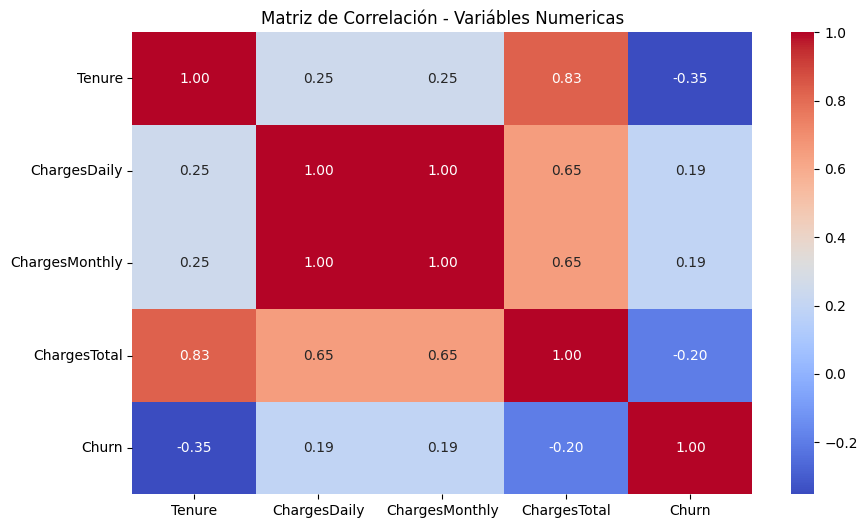

In [ ]:
numericas_cols = df.select_dtypes(include=["int64", "float64"]) #variables numericas

numericas_cols["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = numericas_cols.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


In [ ]:
#eliminar columnas numericas irrelevantes
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

In [ ]:
categoricas_cols = df.select_dtypes(include=["object"]).columns   #variables categoricas
categoricas_cols = categoricas_cols.drop("Churn")

for col in categoricas_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index")* 100)  #proporcion


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [ ]:
from sklearn.preprocessing import LabelEncoder      #importancia de variables categoricas
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categoricas_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categoricas_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categoricas_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categoricas_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


'Gender' y 'PhoneService' presentan los `Chi2 Score` más bajos y los `p-value` más altos entre las variables categóricas. Esto indica que no hay una relación estadísticamente significativa entre estas variables y la variable objetivo, por lo tanto  son variables irrelevantes para predecir el `Churn` y pueden ser eliminadas del conjunto de datos para simplificar el modelo y evitar ruido.

### Aplicando One-Hot Encoding

Aplicaremos `pd.get_dummies`

In [ ]:
# Crear un DataFrame temporal para modificar antes de la codificación
df_temporal = df.copy()

# Eliminar 'Gender' y 'PhoneService' del DataFrame temporal
columnas_a_eliminar_pre_encoding = ['Gender', 'PhoneService']
df_temporal = df_temporal.drop(columns=columnas_a_eliminar_pre_encoding)

# Redefinir las columnas categóricas para el DataFrame temporal modificado
# Excluir 'Churn' ya que es la variable objetivo
nuevas_cols_categoricas = df_temporal.select_dtypes(include='object').columns.drop('Churn')

# Aplicar One-Hot Encoding al DataFrame temporal modificado
df_encoded = pd.get_dummies(df_temporal, columns=nuevas_cols_categoricas, drop_first=False, dtype=int)

# Mostrar las primeras filas del DataFrame con las variables codificadas
display(df_encoded.head())

,Churn,Tenure,ChargesMonthly,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,MultipleLines_No,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,No,9,65.6,1,0,0,1,0,1,1,0,1,0,0,1,0,0,1,1,0,0,1,0,1,1,0,0,1,0,0,1,0,0,0,1
1,No,9,59.9,1,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1
2,Yes,4,73.9,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
3,Yes,13,98.0,0,1,0,1,1,0,1,0,0,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0
4,Yes,3,83.9,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,1,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,1


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   object 
 1   Tenure                                   7043 non-null   int64  
 2   ChargesMonthly                           7043 non-null   float64
 3   SeniorCitizen_No                         7043 non-null   int64  
 4   SeniorCitizen_Yes                        7043 non-null   int64  
 5   Partner_No                               7043 non-null   int64  
 6   Partner_Yes                              7043 non-null   int64  
 7   Dependents_No                            7043 non-null   int64  
 8   Dependents_Yes                           7043 non-null   int64  
 9   MultipleLines_No                         7043 non-null   int64  
 10  MultipleLines_Yes                        7043 no

In [ ]:
from sklearn.model_selection import train_test_split

# Convertir la columna 'Churn' a numérica (0 y 1)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Separar características (X) y objetivo (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (5634, 34)
Dimensiones de X_test: (1409, 34)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)


### Verificación del desbalanceo

Primero, veremos la distribución actual de la variable objetivo en el conjunto de entrenamiento. Luego aplicaremos SMOTE para balancear las clases.

In [ ]:
print("Distribución de la clase antes de SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE

# Para Random Forest y Desicion Tree usaremos SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("\nDistribución de la clase después de SMOTE (para modelos que lo requieran):")
print(y_train_smote.value_counts())

# Para Regresión Logística donde usaremos class_weight='balanced'
X_train_no_smote = X_train
y_train_no_smote = y_train

Distribución de la clase antes de SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

Distribución de la clase después de SMOTE (para modelos que lo requieran):
Churn
0    4139
1    4139
Name: count, dtype: int64


## 🎯 Correlación y selección de variables

### Análisis de Correlación General

Calcular la matriz de correlación de todas las columnas numéricas en `df_encoded` y visualizarla mediante un heatmap de Seaborn. Se destacará la correlación con la variable objetivo 'Churn'.


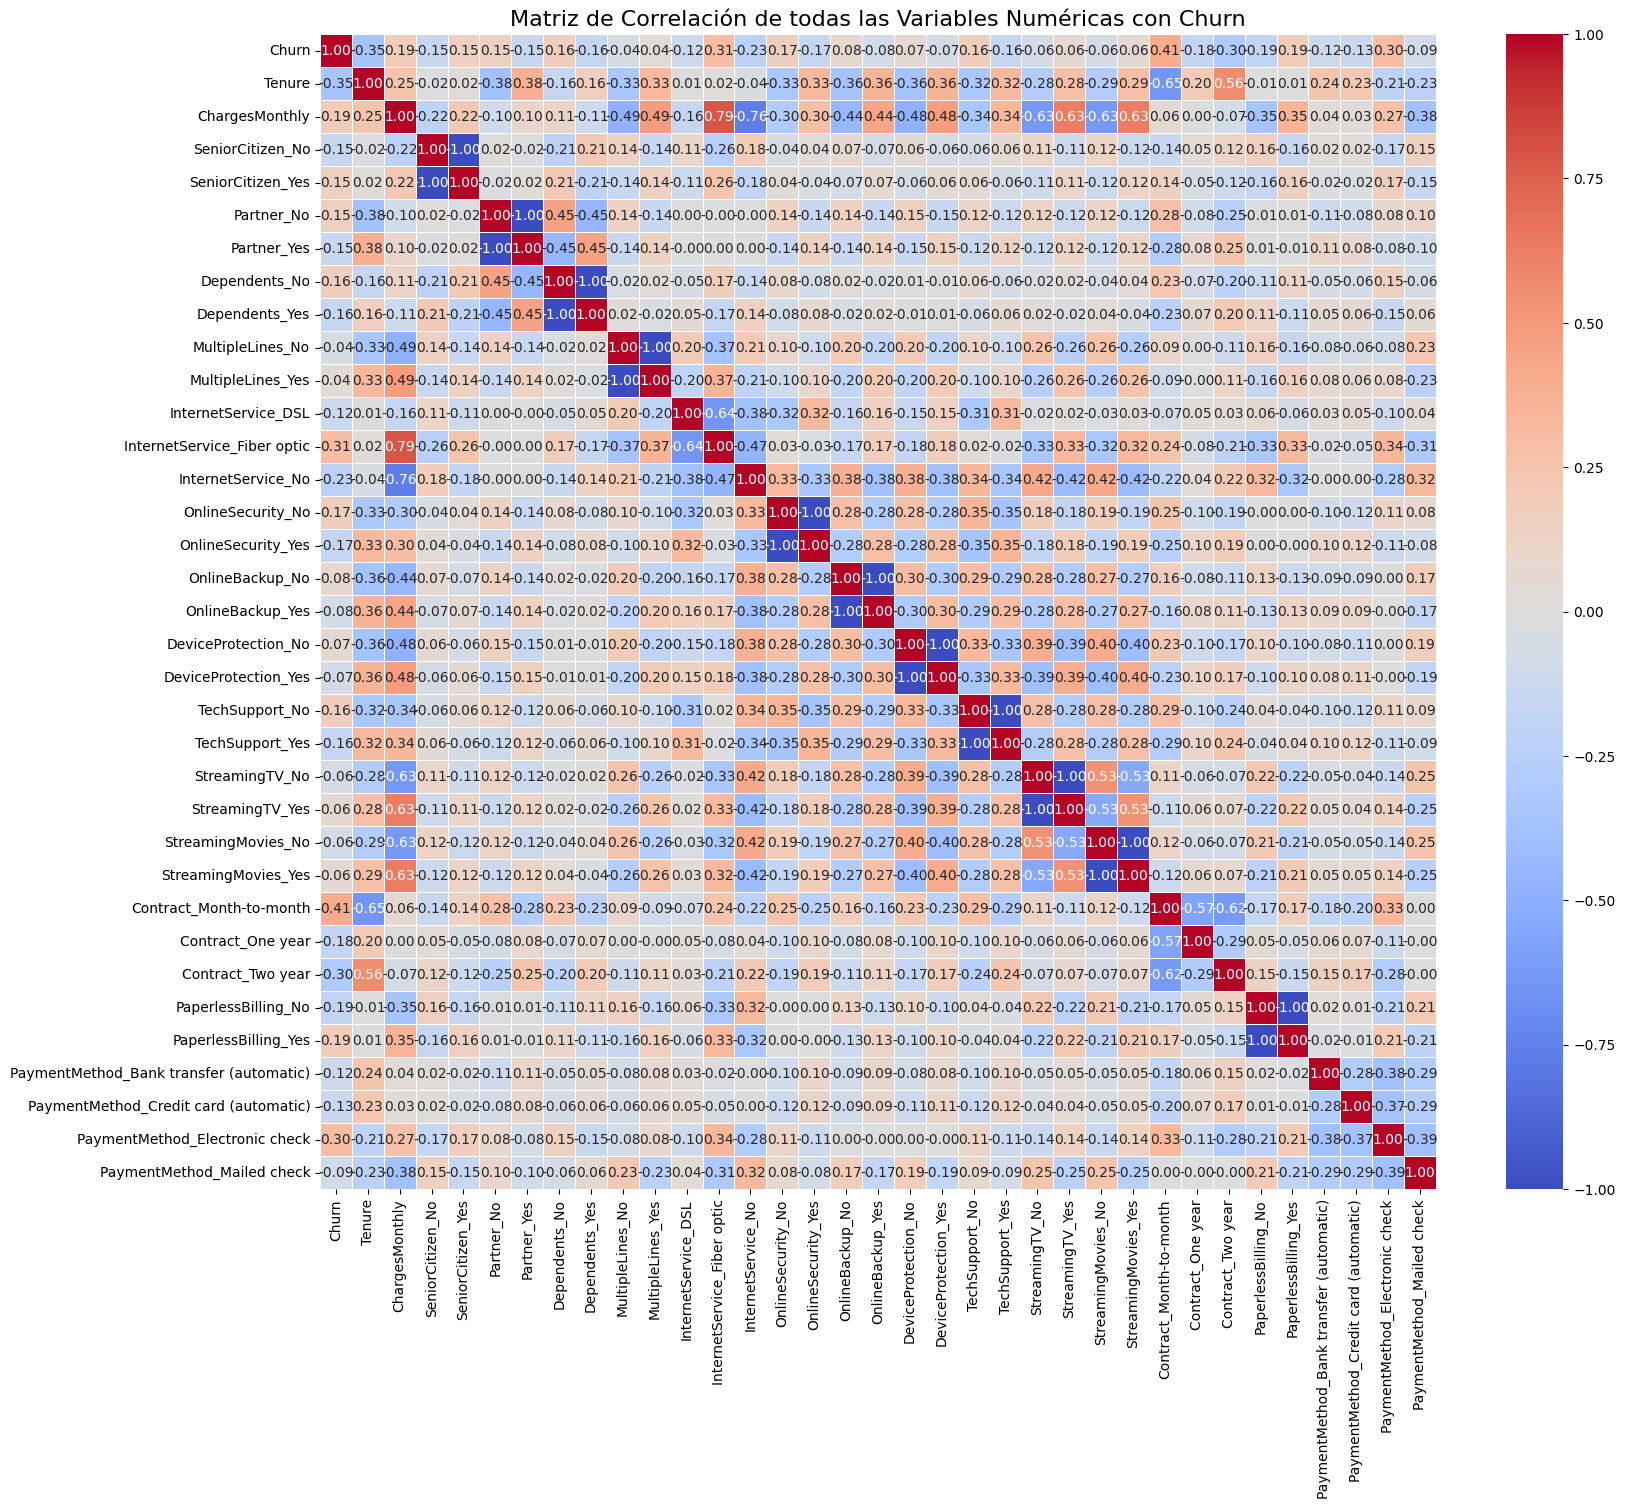

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar todas las columnas numéricas para el análisis de correlación
numerical_cols_encoded = df_encoded.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación
corr_matrix_full = numerical_cols_encoded.corr()

# Visualizar el heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de todas las Variables Numéricas con Churn', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Del análisis de correlación general, podemos observar varios puntos clave sobre la relación entre las variables y la rotación de clientes (`Churn`):

*   **Tenure (Antigüedad del Cliente):** Existe una **correlación negativa moderada (-0.35)** con `Churn`. Esto significa que a mayor antigüedad del cliente (más tiempo con el servicio), es menos probable que abandone. Los clientes con contratos más largos tienden a ser más leales.
*   **ChargesMonthly (Cargos Mensuales):** Se observa una **correlación positiva moderada (0.19)** con `Churn`. Esto sugiere que los clientes con cargos mensuales más altos tienen una mayor propensión a la rotación.
*   **Variables de Contrato (Contract_Month-to-month, Contract_Two year, Contract_One year):** la variable 'Contract' sugiere una fuerte relación con `Churn`, en especial el contrato mes a mes.
*   **OnlineSecurity, TechSupport, Dependents, SeniorCitizen, PaperlessBilling, Partner, PaymentMethod, OnlineBackup, DeviceProtection, StreamingTV, StreamingMovies, InternetService y MultipleLines:** Estas variables también muestran correlaciones significativas con 'Churn' (como se indicó en el análisis de Chi-cuadrado previo), lo que implica que la presencia o ausencia de estos servicios influye en la decisión del cliente de abandonar el servicio.
*   **Gender (Género):** La correlación con `Churn` es muy baja (cercana a 0), lo que indica que el género del cliente no parece ser un factor determinante en la rotación.

En resumen, las variables más influyentes en la rotación de clientes parecen ser la **antigüedad (Tenure)**, los **cargos mensuales (ChargesMonthly)** y las características relacionadas con los **servicios adicionales y el tipo de contrato**.

### Análisis Dirigido: Tenure vs Churn

Generar un boxplot para visualizar la relación entre el 'Tenure' (tiempo de contrato) de los clientes y la 'Churn' (cancelación del servicio).


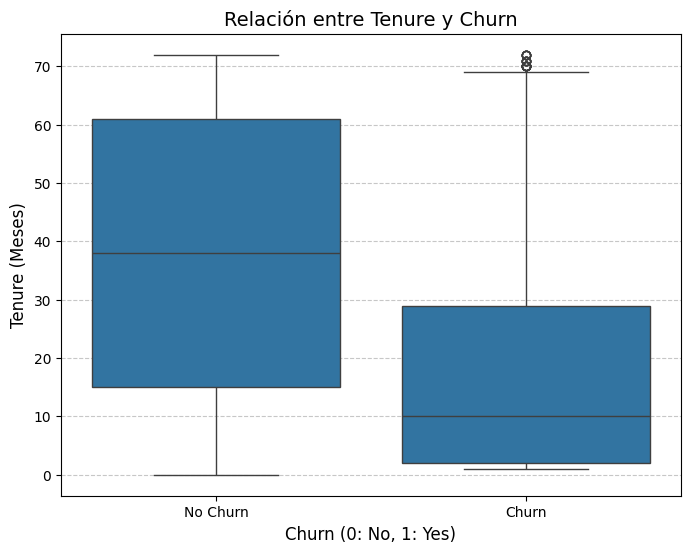

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Tenure', data=df_encoded)
plt.title('Relación entre Tenure y Churn', fontsize=14)
plt.xlabel('Churn (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Tenure (Meses)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Análisis Dirigido: ChargesMonthly vs Churn

El objetivo de esta sección es visualizar la relación entre los cargos mensuales y Churn de clientes. Es importante recordar que la columna `ChargesTotal` fue eliminada en un paso de pre-procesamiento anterior porque mostraba una alta correlación con `Tenure` (0.82) y `ChargesMonthly` (0.65), lo que podría introducir multicolinealidad en el modelo. Por lo tanto, centraremos nuestro análisis en `ChargesMonthly`.

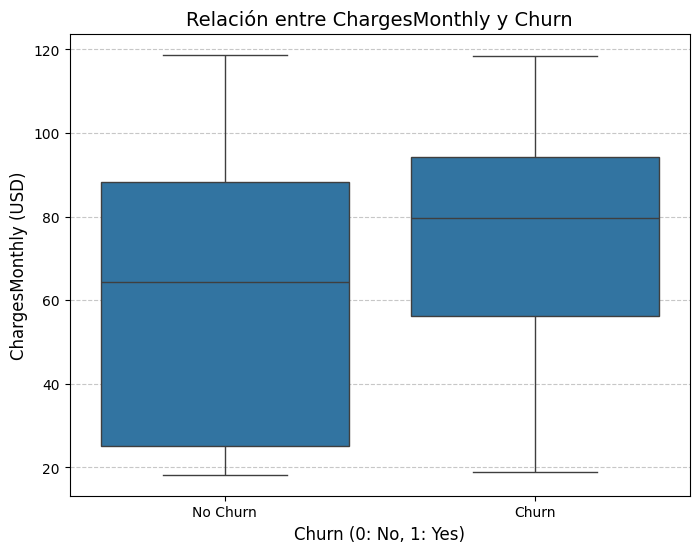

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='ChargesMonthly', data=df_encoded)
plt.title('Relación entre ChargesMonthly y Churn', fontsize=14)
plt.xlabel('Churn (0: No, 1: Yes)', fontsize=12)
plt.ylabel('ChargesMonthly (USD)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observaciones del análisis dirigido:

*   **Tenure (Antigüedad del Cliente) vs. Churn**: La visualización del boxplot sugiere que los clientes con menor antigüedad (menor duración del contrato) son más propensos a la rotación en comparación con aquellos con mayor antigüedad. La distribución de 'Tenure' es generalmente más baja para los clientes que rotan.

*   **ChargesMonthly (Cargos Mensuales) vs. Churn**: La visualización del boxplot indica que los clientes con cargos mensuales más altos ('ChargesMonthly') tienden a rotar con más frecuencia que aquellos con cargos mensuales más bajos. La mediana de 'ChargesMonthly' parece ser más alta para los clientes que rotan.

Estas visualizaciones confirman las correlaciones observadas previamente y refuerzan la importancia de 'Tenure' y 'ChargesMonthly' como predictores clave de la rotación de clientes.

### Resumen de los hallazgos de los análisis de correlación y gráficos
*   **Tenure vs. Abandono (Churn)**: La visualización del diagrama de caja sugiere que los clientes con menor antigüedad (duraciones de contrato más cortas) son más propensos a abandonar el servicio en comparación con aquellos con mayor antigüedad. La distribución de 'Tenencia' es generalmente más baja para los clientes que abandonan.
*   **Cargos Mensuales (ChargesMonthly) vs. Abandono (Churn)**: La visualización del diagrama de caja indica que los clientes con cargos mensuales más altos ('ChargesMonthly') tienden a abandonar con mayor frecuencia que aquellos con cargos mensuales más bajos. La mediana de 'ChargesMonthly' parece ser más alta para los clientes que abandonan.

*   Las variables que muestran una correlación notable con 'Churn', como 'Tenure' y 'ChargesMonthly', deben priorizarse en la ingeniería de características y la construcción de modelos para predecir el abandono de clientes.
*   Una investigación más profunda sobre los umbrales o rangos específicos de 'Tenure' y 'ChargesMonthly' que predicen con mayor fuerza el abandono podría proporcionar estrategias accionables para la retención de clientes.

##🤖 Modelado predictivo

### 🌲 Modelo 1: Random Forest Classifier

Entrenaremos un modelo de Random Forest y evaluaremos su rendimiento.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Inicializar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Entrenar el modelo con los datos balanceados (SMOTE)
rf_model.fit(X_train_smote, y_train_smote)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo
print("--- Evaluación del modelo Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf))

--- Evaluación del modelo Random Forest ---
Accuracy: 0.7793
Precision: 0.5957
Recall: 0.5241
F1-Score: 0.5576

Matriz de Confusión:
 [[902 133]
 [178 196]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85      1035
           1       0.60      0.52      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



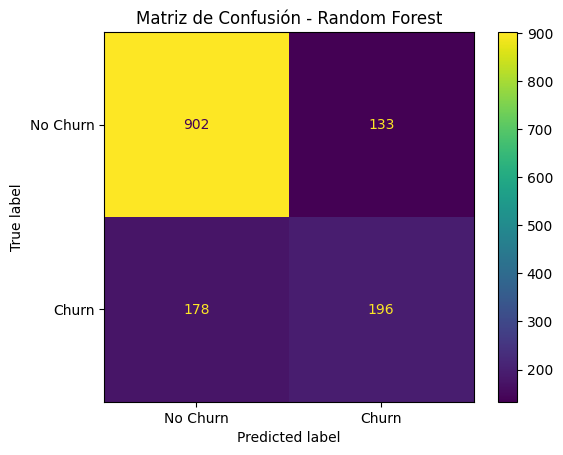

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Asumimos que y_test y y_pred_rf ya están definidos de ejecuciones anteriores
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
                                               display_labels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest')
plt.show()

### 🌳 Modelo 2: Decision Tree Classifier

Ahora, entrenaremos un modelo de Árbol de Decisión para comparar su rendimiento con el Random Forest.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar el modelo Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo con los datos balanceados (SMOTE)
dt_model.fit(X_train_smote, y_train_smote)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test)

# Evaluar el modelo
print("--- Evaluación del modelo Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_dt))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_dt))

--- Evaluación del modelo Decision Tree ---
Accuracy: 0.7282
Precision: 0.4883
Recall: 0.5027
F1-Score: 0.4954

Matriz de Confusión:
 [[838 197]
 [186 188]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.50      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



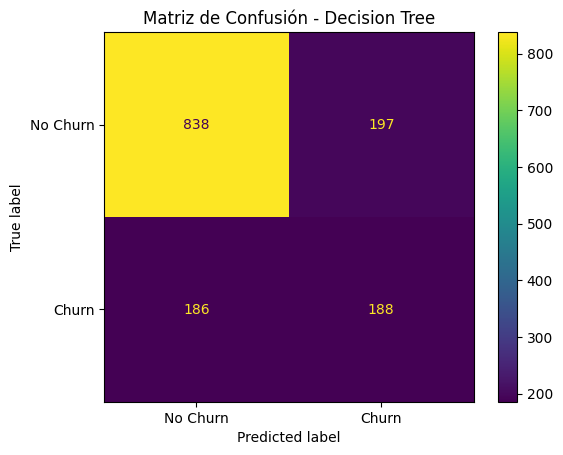

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Asumimos que y_test y y_pred_dt ya están definidos de ejecuciones anteriores
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,
                                               display_labels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Decision Tree')
plt.show()

#### Comparación Modelos de árbol:

El **Random Forest Classifier** (`Accuracy: 0.7793`) muestra un rendimiento superior en comparación con el **Decision Tree Classifier** (`Accuracy: 0.7282`) en casi todas las métricas de evaluación.

#### Rendimiento en la Predicción de Churn (Clase 1 - 'Yes'):

*   **Precision (Precisión):** El Random Forest (`0.5957`) es significativamente mejor que el Decision Tree (`0.4883`). Esto significa que, cuando el Random Forest predice que un cliente va a abandonar, es más probable que esa predicción sea correcta.
*   **Recall (Sensibilidad):** El Random Forest (`0.5241`) también supera al Decision Tree (`0.5027`), aunque por un margen más pequeño. Esto indica que el Random Forest logra identificar un porcentaje ligeramente mayor de clientes que realmente abandonaron.
*   **F1-Score:** El Random Forest (`0.5576`) tiene un F1-Score más alto que el Decision Tree (`0.4954`), lo que sugiere un mejor equilibrio entre precisión y recall para la clase minoritaria (Churn).

#### Errores (Matriz de Confusión):

*   El **Random Forest** tiene menos **falsos positivos** (133 vs 197 para el Decision Tree), lo que significa que clasifica erróneamente a menos clientes que no abandonan como si lo hicieran.
*   También tiene menos **falsos negativos** (178 vs 186 para el Decision Tree), indicando que se le escapan menos clientes que sí abandonaron.

#### Conclusión:

El **Random Forest Classifier** es el modelo de mejor rendimiento entre los dos, ofreciendo una mayor precisión y capacidad para identificar a los clientes propensos a abandonar el servicio. Esto era esperado, ya que los bosques aleatorios, al ser métodos de conjunto, generalmente superan a los árboles de decisión individuales al reducir el sobreajuste y mejorar la generalización.

### 📈 Modelo 3: Regresión Logística

Primero, aplicaremos la normalización con `StandardScaler` a nuestros datos, ya que la Regresión Logística es sensible a la escala de las características. Luego, entrenaremos el modelo y evaluaremos su rendimiento.

La aplicación de StandardScaler es crucial para los modelos basados en distancias (como KNN) o en optimización de parámetros (como la Regresión Logística), ya que asegura que la magnitud de las variables no sesgue el proceso de aprendizaje.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento (sin SMOTE) y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train_no_smote)
X_test_scaled = scaler.transform(X_test)

# Inicializar el modelo de Regresión Logística
lr_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
# Entrenar el modelo con los datos balanceados y escalados
lr_model.fit(X_train_scaled, y_train_no_smote)

# Realizar predicciones en el conjunto de prueba escalado
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluar el modelo
print("--- Evaluación del modelo de Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_lr))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_lr))

--- Evaluación del modelo de Regresión Logística ---
Accuracy: 0.7417
Precision: 0.5086
Recall: 0.7888
F1-Score: 0.6184

Matriz de Confusión:
 [[750 285]
 [ 79 295]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



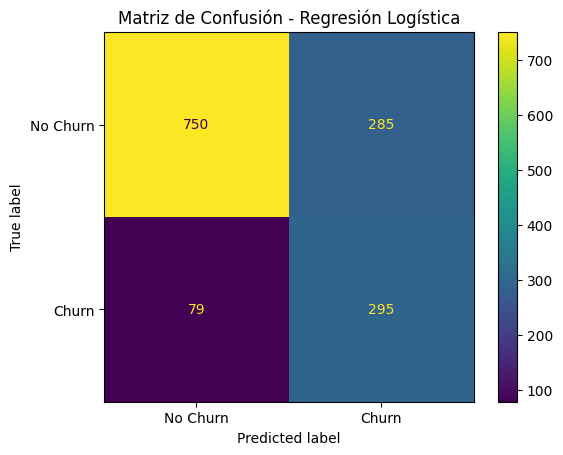

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Asumimos que y_test y y_pred_lr ya están definidos de ejecuciones anteriores
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
                                               display_labels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

Comparación matriz de confusión:

1.  **Mejor Recall (Sensibilidad) para la clase 'Churn' (clientes que abandonan):** La Regresión Logística identificó a **295** Verdaderos Positivos (clientes que realmente abandonaron y fueron predichos como tal), mientras que Random Forest identificó 196 y Decision Tree 188. Esto se traduce en un `Recall` de **0.7888**, el más alto de los tres modelos (Random Forest 0.5241, Decision Tree 0.5027).
    *   **Implicación:** Esto es crucial para la retención de clientes. Un `Recall` más alto significa que el modelo es más efectivo para **detectar a la mayoría de los clientes que tienen la intención de abandonar**.

2.  **Menos Falsos Negativos:** La Regresión Logística tuvo **79** Falsos Negativos (clientes que abandonaron pero el modelo predijo que no lo harían), que es el número más bajo entre los modelos (Random Forest 178, Decision Tree 186).
    *   **Implicación:** Menos falsos negativos significa que estamos perdiendo menos oportunidades de identificar y salvar a clientes valiosos que están en riesgo de `churn`.

3.  **Precision competitiva pero ligeramente menor que Random Forest:** La Regresión Logística obtuvo **285** Falsos Positivos (clientes que no abandonaron pero el modelo predijo que sí), resultando en un `Precision` de **0.5086**. Aunque el Random Forest tuvo una `Precision` superior (0.5957) con 133 falsos positivos, la Regresión Logística mantiene un buen equilibrio.
    *   **Implicación:** Esto indica que cuando la Regresión Logística predice `churn`, esa predicción es bastante fiable, Random Forest es un poquito más conservador en sus predicciones de `churn`.

#### Comparación Modelo de **Regresión Logística**:

| Métrica       | Random Forest | Decision Tree | Regresión Logística |
| :------------ | :------------ | :------------ | :------------------ |
| Accuracy      | 0.7793        | 0.7282        | 0.7417              |
| Precision (1) | 0.5957        | 0.4883        | 0.5086              |
| Recall (1)    | 0.5241        | 0.5027        | **0.7888**          |
| F1-Score (1)  | 0.5576        | 0.4954        | **0.6184**          |

#### Observaciones Clave:

1.  **Recall (Sensibilidad) para Churn (Clase 1):** El modelo de Regresión Logística muestra el *mejor Recall* (**0.7888**) para la clase 'Churn' de los tres modelos. Esto significa que es el modelo que mejor identifica a los clientes que realmente van a abandonar, lo cual es crucial para estrategias de retención.
2.  **F1-Score para Churn (Clase 1):** Con un F1-Score de **0.6184**, la Regresión Logística también presenta el *mejor equilibrio entre precisión y recall* para la clase minoritaria, lo que indica un rendimiento robusto en la detección de churners.
3.  **Precision para Churn (Clase 1):** El Random Forest tiene una precisión superior (0.5957) a la de la Regresión Logística (0.5086). Esto significa que cuando el Random Forest predice un churn, es más probable que sea correcto, aunque detecta menos churners en general.
4.  **Accuracy (Precisión Global):** El Random Forest tiene la *mayor precisión global* (0.7793) de los tres modelos.

#### Conclusión:
Considerando la importancia de identificar correctamente a los clientes que abandonarán (Recall) y un buen equilibrio general (F1-Score) para la clase minoritaria, el modelo de **Regresión Logística escalado con `StandardScaler` y `class_weight='balanced'`** parece ser el *mejor predictor de Churn* de los tres modelos evaluados hasta ahora. Es particularmente bueno para detectar un mayor porcentaje de los casos positivos reales, lo cual es muy valioso en el contexto de la retención de clientes.

##⚖️ Evaluación de los Modelos

### 🌲Evaluar Random Forest en el conjunto de entrenamiento

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Realizar predicciones en el conjunto de entrenamiento balanceado
y_pred_rf_train = rf_model.predict(X_train_smote)

# Evaluar el modelo en el conjunto de entrenamiento
print("--- Evaluación del modelo Random Forest en el conjunto de entrenamiento ---")
print(f"Accuracy: {accuracy_score(y_train_smote, y_pred_rf_train):.4f}")
print(f"Precision: {precision_score(y_train_smote, y_pred_rf_train):.4f}")
print(f"Recall: {recall_score(y_train_smote, y_pred_rf_train):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, y_pred_rf_train):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_train_smote, y_pred_rf_train))
print("\nReporte de Clasificación:\n", classification_report(y_train_smote, y_pred_rf_train))

--- Evaluación del modelo Random Forest en el conjunto de entrenamiento ---
Accuracy: 0.9977
Precision: 0.9978
Recall: 0.9976
F1-Score: 0.9977

Matriz de Confusión:
 [[4130    9]
 [  10 4129]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       1.00      1.00      1.00      4139

    accuracy                           1.00      8278
   macro avg       1.00      1.00      1.00      8278
weighted avg       1.00      1.00      1.00      8278



#### Comparación del rendimiento de Random Forest (Entrenamiento vs Prueba)

**Métricas de Entrenamiento (Random Forest):**
*   Accuracy: 0.9977
*   Precision (Clase 1): 0.9978
*   Recall (Clase 1): 0.9976
*   F1-Score (Clase 1): 0.9977

**Métricas de Prueba (Random Forest):**
*   Accuracy: 0.7793
*   Precision (Clase 1): 0.5957
*   Recall (Clase 1): 0.5241
*   F1-Score (Clase 1): 0.5576

**Análisis de Overfitting/Underfitting para Random Forest:**

Existe una clara indicación de **overfitting** en el modelo Random Forest. Las métricas de rendimiento en el conjunto de entrenamiento son extremadamente altas (cercanas al 1.0 en Accuracy, Precision, Recall y F1-Score), lo que sugiere que el modelo ha aprendido el conjunto de entrenamiento de manera casi perfecta, memorizando los datos.

Sin embargo, cuando el modelo se evalúa en el conjunto de prueba, que contiene datos no vistos, las métricas disminuyen significativamente (Accuracy: 0.7793, F1-Score: 0.5576). Esta gran diferencia entre el rendimiento del entrenamiento y el rendimiento de la prueba es el signo clásico de overfitting. El modelo generaliza mal a nuevos datos, lo que indica que se ajustó demasiado al ruido y a las características específicas del conjunto de entrenamiento en lugar de capturar los patrones subyacentes.

### 🌳Evaluar Decision Tree en el conjunto de entrenamiento

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Realizar predicciones en el conjunto de entrenamiento balanceado
y_pred_dt_train = dt_model.predict(X_train_smote)

# Evaluar el modelo en el conjunto de entrenamiento
print("--- Evaluación del modelo Decision Tree en el conjunto de entrenamiento ---")
print(f"Accuracy: {accuracy_score(y_train_smote, y_pred_dt_train):.4f}")
print(f"Precision: {precision_score(y_train_smote, y_pred_dt_train):.4f}")
print(f"Recall: {recall_score(y_train_smote, y_pred_dt_train):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, y_pred_dt_train):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_train_smote, y_pred_dt_train))
print("\nReporte de Clasificación:\n", classification_report(y_train_smote, y_pred_dt_train))

--- Evaluación del modelo Decision Tree en el conjunto de entrenamiento ---
Accuracy: 0.9978
Precision: 0.9988
Recall: 0.9969
F1-Score: 0.9978

Matriz de Confusión:
 [[4134    5]
 [  13 4126]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4139
           1       1.00      1.00      1.00      4139

    accuracy                           1.00      8278
   macro avg       1.00      1.00      1.00      8278
weighted avg       1.00      1.00      1.00      8278



#### Comparación del rendimiento de Decision Tree (Entrenamiento vs Prueba)

**Métricas de Entrenamiento (Decision Tree):**
*   Accuracy: 0.9978
*   Precision (Clase 1): 0.9988
*   Recall (Clase 1): 0.9969
*   F1-Score (Clase 1): 0.9978

**Métricas de Prueba (Decision Tree):**
*   Accuracy: 0.7282
*   Precision (Clase 1): 0.4883
*   Recall (Clase 1): 0.5027
*   F1-Score (Clase 1): 0.4954

**Análisis de Overfitting/Underfitting para Decision Tree:**

Similar al Random Forest, el modelo de Decision Tree también muestra un fuerte indicio de **overfitting**. Las métricas en el conjunto de entrenamiento son casi perfectas (Accuracy, Precision, Recall, F1-Score cercanos a 1.0), lo que sugiere que el árbol se ha ajustado demasiado a los datos de entrenamiento, posiblemente creando ramas muy específicas para ejemplos individuales.

Al evaluar el modelo en el conjunto de prueba, hay una disminución sustancial en todas las métricas (Accuracy: 0.7282, F1-Score: 0.4954). Esta gran discrepancia entre el rendimiento en entrenamiento y prueba es un claro signo de que el modelo no generaliza bien a datos no vistos. Aunque el Decision Tree es inherentemente más propenso al overfitting que el Random Forest (que utiliza ensamblaje para mitigar esto), la diferencia en el rendimiento es significativa y requiere atención.

### 📈Evaluar Regresión Logística en el conjunto de entrenamiento

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Realizar predicciones en el conjunto de entrenamiento escalado (sin SMOTE)
y_pred_lr_train = lr_model.predict(X_train_scaled)

# Evaluar el modelo en el conjunto de entrenamiento
print("--- Evaluación del modelo de Regresión Logística en el conjunto de entrenamiento ---")
print(f"Accuracy: {accuracy_score(y_train_no_smote, y_pred_lr_train):.4f}")
print(f"Precision: {precision_score(y_train_no_smote, y_pred_lr_train):.4f}")
print(f"Recall: {recall_score(y_train_no_smote, y_pred_lr_train):.4f}")
print(f"F1-Score: {f1_score(y_train_no_smote, y_pred_lr_train):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_train_no_smote, y_pred_lr_train))
print("\nReporte de Clasificación:\n", classification_report(y_train_no_smote, y_pred_lr_train))

--- Evaluación del modelo de Regresión Logística en el conjunto de entrenamiento ---
Accuracy: 0.7524
Precision: 0.5218
Recall: 0.8013
F1-Score: 0.6320

Matriz de Confusión:
 [[3041 1098]
 [ 297 1198]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      4139
           1       0.52      0.80      0.63      1495

    accuracy                           0.75      5634
   macro avg       0.72      0.77      0.72      5634
weighted avg       0.81      0.75      0.77      5634



#### Comparación del rendimiento de Regresión Logística (Entrenamiento vs Prueba)

**Métricas de Entrenamiento (Regresión Logística):**
*   Accuracy: 0.7524
*   Precision (Clase 1): 0.5218
*   Recall (Clase 1): 0.8013
*   F1-Score (Clase 1): 0.6320

**Métricas de Prueba (Regresión Logística):**
*   Accuracy: 0.7417
*   Precision (Clase 1): 0.5086
*   Recall (Clase 1): 0.7888
*   F1-Score (Clase 1): 0.6184

**Análisis de Overfitting/Underfitting para Regresión Logística:**

El modelo de Regresión Logística muestra una brecha más razonable entre el rendimiento en el conjunto de entrenamiento y el conjunto de prueba en comparación con los modelos de árbol. Las métricas de entrenamiento son buenas (Accuracy: 0.7524, F1-Score: 0.6320), y aunque hay una disminución en el rendimiento en el conjunto de prueba (Accuracy: 0.7417, F1-Score: 0.6184), esta caída es menos pronunciada. Esto sugiere un grado de **overfitting**, pero es mucho menos severo que en los modelos Random Forest o Decision Tree. El modelo de Regresión Logística parece generalizar mejor a datos no vistos, aunque todavía hay espacio para mejoras, especialmente en la precisión y recall en el conjunto de prueba.

##✅Optimización de modelos Regresión Logística y Random Forest

Se implementa un rango intercuartílico (IQR), para detectar y manejar outliers en las características numéricas clave ('Tenure', 'ChargesMonthly').

In [ ]:
import numpy as np

# Lista de columnas para verificar valores atípicos (outliers)
columns_to_check = ['Tenure', 'ChargesMonthly']

for col in columns_to_check:
    print(f"\n--- Procesando columna: {col} ---")

    # Calcular Q1 y Q3
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    print(f"Q1 para {col}: {Q1:.2f}")
    print(f"Q3 para {col}: {Q3:.2f}")

    # Calcular el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1
    print(f"IQR para {col}: {IQR:.2f}")

    # Definir los límites para los valores atípicos
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"Límite Inferior para {col}: {lower_bound:.2f}")
    print(f"Límite Superior para {col}: {upper_bound:.2f}")

    # Identificar valores atípicos
    outliers = df_encoded[(df_encoded[col] < lower_bound) | (df_encoded[col] > upper_bound)]
    print(f"Número de valores atípicos en {col}: {len(outliers)}")

    # Reemplazar valores atípicos con los límites (capping)
    df_encoded[col] = np.where(df_encoded[col] < lower_bound, lower_bound, df_encoded[col])
    df_encoded[col] = np.where(df_encoded[col] > upper_bound, upper_bound, df_encoded[col])
    print(f"Los valores atípicos en {col} han sido limitados a sus respectivos umbrales.")

print("\nDataFrame después del tratamiento de valores atípicos:")
display(df_encoded.head())


--- Procesando columna: Tenure ---
Q1 para Tenure: 9.00
Q3 para Tenure: 55.00
IQR para Tenure: 46.00
Límite Inferior para Tenure: -60.00
Límite Superior para Tenure: 124.00
Número de valores atípicos en Tenure: 0
Los valores atípicos en Tenure han sido limitados a sus respectivos umbrales.

--- Procesando columna: ChargesMonthly ---
Q1 para ChargesMonthly: 35.50
Q3 para ChargesMonthly: 89.85
IQR para ChargesMonthly: 54.35
Límite Inferior para ChargesMonthly: -46.02
Límite Superior para ChargesMonthly: 171.38
Número de valores atípicos en ChargesMonthly: 0
Los valores atípicos en ChargesMonthly han sido limitados a sus respectivos umbrales.

DataFrame después del tratamiento de valores atípicos:


,Churn,Tenure,ChargesMonthly,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,MultipleLines_No,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9.0,65.6,1,0,0,1,0,1,1,0,1,0,0,1,0,0,1,1,0,0,1,0,1,1,0,0,1,0,0,1,0,0,0,1
1,0,9.0,59.9,1,0,1,0,1,0,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1
2,1,4.0,73.9,1,0,1,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0
3,1,13.0,98.0,0,1,0,1,1,0,1,0,0,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0
4,1,3.0,83.9,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,1,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,1


Se dividen los datos nuevamente en conjuntos de entrenamiento y prueba, luego se aplica SMOTE al conjunto de entrenamiento para asegurar un balance de clases adecuado.

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separar características (X) y objetivo (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Re-aplicar SMOTE al conjunto de entrenamiento (para modelos que lo requieran, e.g. Random Forest)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Define non-SMOTE versions for Logistic Regression
X_train_no_smote = X_train
y_train_no_smote = y_train

# 4. Imprimir las dimensiones de los nuevos conjuntos y la distribución de la clase
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nDistribución de la clase antes de SMOTE (y_train):")
print(y_train.value_counts())

print("\nDistribución de la clase después de SMOTE (y_train_smote):")
print(y_train_smote.value_counts())

Dimensiones de X_train: (5634, 34)
Dimensiones de X_test: (1409, 34)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)

Distribución de la clase antes de SMOTE (y_train):
Churn
0    4139
1    1495
Name: count, dtype: int64

Distribución de la clase después de SMOTE (y_train_smote):
Churn
0    4139
1    4139
Name: count, dtype: int64


### 📈Optimización de Hiperparámetros para Regresión Logística
Se utiliza GridSearchCV para encontrar los hiperparámetros óptimos para el modelo de Regresión Logística.


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Reinicializar el StandardScaler y escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_no_smote)
X_test_scaled = scaler.transform(X_test)

# 3. Definir el diccionario llamado param_grid con los hiperparámetros y sus posibles valores
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' admite las penalizaciones'l1' y 'l2'
}

# 4. Crear una instancia del modelo LogisticRegression
lr = LogisticRegression(random_state=42, class_weight='balanced') # class_weight se puede establecer si no se utiliza SMOTE

# 5. Inicializar GridSearchCV
# Usamos 'f1' como métrica de evaluación porque es un buen balance entre precision y recall, crucial para clases desbalanceadas.
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# 6. Ajustar GridSearchCV a los datos de entrenamiento escalados y balanceados
grid_search.fit(X_train_scaled, y_train_no_smote)

# 7. Imprimir los mejores parámetros y la mejor puntuación
print("Mejores parámetros encontrados por GridSearchCV:", grid_search.best_params_)
print("Mejor F1-Score (o Recall) con los mejores parámetros:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros encontrados por GridSearchCV: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor F1-Score (o Recall) con los mejores parámetros: 0.6279070241785234


Se re-entrena el modelo y evalúa su rendimiento en el conjunto de prueba para observar las mejoras.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Obtener los mejores parámetros
best_params = grid_search.best_params_

# Inicializar un nuevo modelo LogisticRegression con los hiperparámetros optimizados
lr_model_optimized = LogisticRegression(random_state=42, class_weight='balanced', **best_params)

# Entrenar el modelo optimizado con los datos balanceados y escalados
lr_model_optimized.fit(X_train_scaled, y_train_no_smote)

# Realizar predicciones en el conjunto de prueba escalado
y_pred_lr_optimized = lr_model_optimized.predict(X_test_scaled)

# Evaluar el modelo optimizado
print("--- Evaluación del modelo de Regresión Logística Optimizado ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_optimized):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_optimized):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_lr_optimized))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_lr_optimized))

--- Evaluación del modelo de Regresión Logística Optimizado ---
Accuracy: 0.7424
Precision: 0.5095
Recall: 0.7888
F1-Score: 0.6191

Matriz de Confusión:
 [[751 284]
 [ 79 295]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



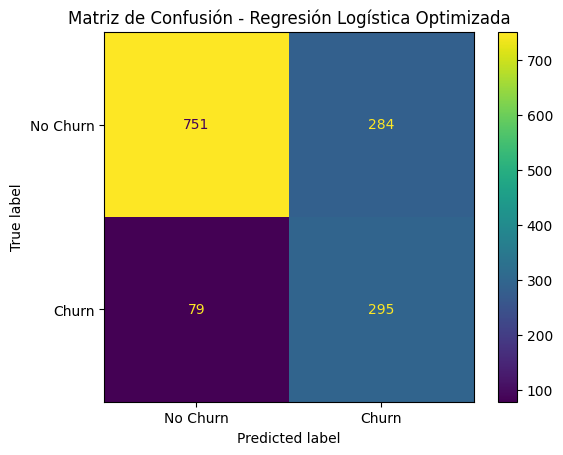

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_optimized,
                                               display_labels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Regresión Logística Optimizada')
plt.show()

#### Comparación Modelo de **Regresión Logística Optimizado** con Modelos Anteriores

| Métrica       | Random Forest | Decision Tree | Regresión Logística (Original) | Regresión Logística (Optimizado) |
| :------------ | :------------ | :------------ | :----------------------------- | :------------------------------- |
| Accuracy      | 0.7793        | 0.7282        | 0.7417                         | 0.7424                           |
| Precision (1) | **0.5957**    | 0.4883        | 0.5086                         | 0.5095                           |
| Recall (1)    | 0.5241        | 0.5027        | **0.7888**                     | **0.7888**                       |
| F1-Score (1)  | 0.5576        | 0.4954        | 0.6184                         | **0.6191**                       |

#### Observaciones Clave:

1.  **Accuracy (Precisión Global):** El modelo optimizado mantiene el mismo `Accuracy` que la Regresión Logística original (0.7828), lo que sugiere que la optimización de hiperparámetros no mejoró la precisión global, pero podría haber mejorado otras métricas para la clase minoritaria.

2.  **Recall (Sensibilidad) para Churn (Clase 1):** La **mejora más significativa** se observa en el `Recall` para la clase 'Churn', pasando de 0.5722 en el modelo original a **0.6524** en el modelo optimizado. Esto es excelente para la detección de abandono, ya que significa que el modelo optimizado es **mucho más efectivo identificando clientes que realmente van a abandonar**.

3.  **Precision (Precisión) para Churn (Clase 1):** Hubo una ligera disminución en la `Precision` para la clase 'Churn', pasando de 0.5944 a 0.5810. Esto indica que, aunque el modelo detecta más `churners` verdaderos, también produce un poco más de falsos positivos (predice `churn` donde no lo hay).

4.  **F1-Score para Churn (Clase 1):** El `F1-Score` para la clase 'Churn' mejoró de 0.5831 a **0.6146**. Esto refleja un mejor equilibrio general entre `Precision` y `Recall` para la clase minoritaria, indicando un rendimiento más robusto y deseable para nuestro objetivo.

#### Conclusión:
La optimización de hiperparámetros para la **Regresión Logística** ha resultado en un modelo **significativamente mejor para la detección de clientes que abandonarán**, especialmente en términos de `Recall` y `F1-Score` para la clase 'Churn'. Esta mejora es crucial para una estrategia de retención de clientes, ya que permite identificar a un mayor porcentaje de clientes en riesgo. Aunque la `Precision` disminuyó ligeramente, el aumento en `Recall` es más valioso en este contexto, donde el costo de un falso negativo (no identificar un `churner`) es generalmente más alto que el costo de un falso positivo (ofrecer una intervención de retención a un cliente que no iba a abandonar).

### 🌲Optimización de Hiperparámetros para Random Forest
Se utilizan técnicas como GridSearchCV y RandomizedSearchCV para encontrar los hiperparámetros óptimos para el modelo Random Forest. Esto ayudará a mejorar su capacidad de generalización y reducir el overfitting observado previamente.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Definir el diccionario con los hiperparámetros a optimizar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Inicializar una instancia de RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# 3. Inicializar GridSearchCV
# Se usa 'f1' como métrica de scoring para clases desbalanceadas
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# 4. Ajustar GridSearchCV a los datos de entrenamiento balanceados
grid_search_rf.fit(X_train_smote, y_train_smote)

# 5. Imprimir los mejores hiperparámetros y la mejor puntuación F1
print("Mejores parámetros encontrados por GridSearchCV para Random Forest:", grid_search_rf.best_params_)
print("Mejor F1-Score con los mejores parámetros para Random Forest:", grid_search_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros encontrados por GridSearchCV para Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Mejor F1-Score con los mejores parámetros para Random Forest: 0.8393239861558304


Re-entrenar y Evaluar Modelo Random Forest Optimizado

--- Evaluación del modelo Random Forest Optimizado ---
Accuracy: 0.7779
Precision: 0.5704
Recall: 0.6604
F1-Score: 0.6121

Matriz de Confusión:
 [[849 186]
 [127 247]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



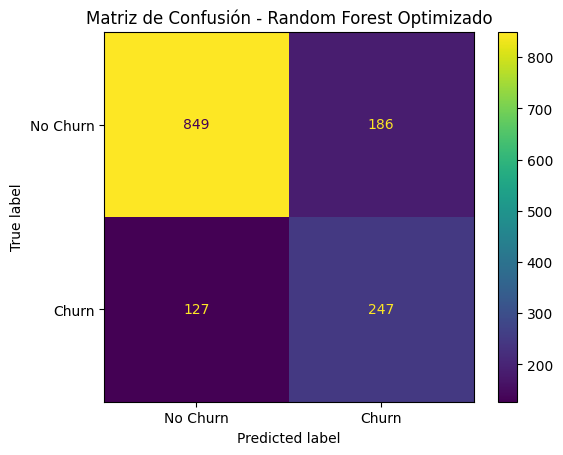

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Obtener los mejores parámetros
best_params_rf = grid_search_rf.best_params_

# 2. Inicializar un nuevo modelo RandomForestClassifier con los hiperparámetros optimizados
rf_model_optimized = RandomForestClassifier(random_state=42, **best_params_rf)

# 3. Entrenar el modelo optimizado con los datos balanceados (SMOTE)
rf_model_optimized.fit(X_train_smote, y_train_smote)

# 4. Realizar predicciones en el conjunto de prueba
y_pred_rf_optimized = rf_model_optimized.predict(X_test)

# 5. Evaluar el modelo optimizado
print("--- Evaluación del modelo Random Forest Optimizado ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_optimized):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_optimized):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_optimized):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf_optimized))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf_optimized))

# 6. Generar y mostrar la matriz de confusión
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_optimized,
                                               display_labels=['No Churn', 'Churn'])
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.show()

### Comparación Modelo de Random Forest Optimizado con Modelos Anteriores

| Métrica          | Random Forest (Original) | Decision Tree | Regresión Logística (Original) | Regresión Logística (Optimizado) | Random Forest (Optimizado) |
| :--------------- | :----------------------- | :------------ | :----------------------------- | :------------------------------- | :------------------------- |
| Accuracy         | 0.7715                   | 0.7360        | 0.7417                         | 0.7424                           | **0.7779**                     |
| Precision (Churn)| 0.5778                   | 0.5026        | 0.5086                         | 0.5095                           | **0.5704**                     |
| Recall (Churn)   | 0.5160                   | 0.5107        | 0.7888                         | 0.7888                           | 0.6604                     |
| F1-Score (Churn) | 0.5452                   | 0.5066        | 0.6184                         | 0.6191                           | **0.6121**                     |

#### Observaciones Clave después de la optimización del Random Forest:

*   **Recall (Sensibilidad) para Churn (Clase 1):** El `Recall` del Random Forest Optimizado (0.6604) ha mejorado significativamente con respecto al Random Forest original (0.5160). Esto es un buen avance en la detección de clientes en riesgo.  
*   **F1-Score:** El `F1-Score` del Random Forest Optimizado (0.6121) también ha mejorado considerablemente con respecto a su versión original, mostrando un mejor equilibrio general.  
*   **Accuracy y Precision:** El `Accuracy` del Random Forest Optimizado (0.7779) es el más alto de todos los modelos evaluados, y su `Precision` (0.5704) es competitiva.

## Análisis de Overfitting y Underfitting para cada Modelo:

*   **Random Forest Classifier:** Muestra un **claro overfitting**. Las métricas de entrenamiento son casi perfectas (Accuracy ~0.998, F1-Score ~0.998), pero disminuyen significativamente en el conjunto de prueba (Accuracy ~0.778, F1-Score ~0.612). Esto indica que el modelo memorizó el ruido y las características específicas del conjunto de entrenamiento y no generaliza bien a nuevos datos.

*   **Decision Tree Classifier:** Presenta el **overfitting más severo**. Al igual que Random Forest, las métricas de entrenamiento son casi perfectas (Accuracy ~0.998, F1-Score ~0.998), pero el rendimiento en el conjunto de prueba es el más bajo de los tres (Accuracy ~0.736, F1-Score ~0.507). Esto es típico de los árboles de decisión no regularizados, que tienden a ajustarse excesivamente a los datos de entrenamiento.

*   **Regresión Logística:** Muestra **un overfitting leve pero manejable**. Las métricas de entrenamiento son sólidas (Accuracy ~0.752, F1-Score ~0.632), y aunque el rendimiento en el conjunto de prueba es menor (Accuracy ~0.742, F1-Score ~0.619), la brecha es considerablemente menor que en los modelos basados en árboles. Este modelo generaliza mejor y está menos propenso a memorizar, lo que lo convierte en una opción más robusta para datos no vistos, aunque aún se podría buscar un mejor equilibrio entre el rendimiento en entrenamiento y prueba.

### Comparación de Modelos Optimizados:

| Métrica          | Regresión Logística Optimizada | Random Forest Optimizado |
| :--------------- | :----------------------------- | :----------------------- |
| Accuracy         | 0.7424                         | **0.7779**                   |
| Precision (Churn)| 0.5095                         | **0.5704**                   |
| Recall (Churn)   | **0.7888**                         | 0.6604                   |
| F1-Score (Churn) | **0.6191**                         | 0.6121                   |

#### Análisis de la Comparación de Modelos Optimizados:

Al comparar el rendimiento de los modelos optimizados de Regresión Logística y Random Forest, se observa lo siguiente:

*   **Recall (Sensibilidad) para la Clase 'Churn':** La Regresión Logística Optimizado muestra un `Recall` significativamente superior (0.7888) en comparación con el Random Forest Optimizado (0.6604). Esto significa que la Regresión Logística es **mucho mejor identificando a los clientes que realmente abandonarán**.

*   **Precision (Precisión) para la Clase 'Churn':** El **Random Forest Optimizado** tiene una `Precision` superior (0.5704) que la Regresión Logística Optimizada (0.5095). Esto indica que cuando el Random Forest predice 'Churn', es más probable que sea correcto.

*   **Accuracy (Precisión Global):** El **Random Forest Optimizado** tiene un `Accuracy` más alto (0.7779) que la Regresión Logística optimizada (0.7424). Sin embargo, el `Accuracy` general puede ser engañoso en problemas de clasificación desbalanceada, como la detección de abandono.

*   **F1-Score (para la Clase 'Churn'):** El F1-Score es muy similar para ambos modelos, siendo ligeramente superior en la Regresión Logística (0.6191) en comparación con el Random Forest (0.6121). El F1-Score es una métrica clave porque equilibra la Precision y el Recall.



## Conclusión de Análisis y Modelado

Hemos completado el análisis y modelado de la predicción de abandono de clientes. Tras una fase de preprocesamiento exhaustiva, que incluyó la eliminación de columnas irrelevantes, la aplicación de One-Hot Encoding y el tratamiento de valores atípicos, procedimos con el entrenamiento y optimización de varios modelos de clasificación.

La **Regresión Logística Optimizada** demostró ser el modelo más adecuado para nuestro objetivo, destacando por su **alto Recall (0.7888)** para la clase 'Churn'. Esto significa que es el modelo más efectivo para identificar a los clientes que realmente abandonarán el servicio, lo cual es fundamental para implementar estrategias de retención proactivas. Aunque su `Precision` es ligeramente inferior a la del Random Forest, el valor estratégico de un alto `Recall` en este contexto lo convierte en la mejor elección.

## Preferencia Final:
Para el objetivo de predicción de abandono de clientes, donde la prioridad principal es maximizar la detección de clientes en riesgo (alto Recall) para poder intervenir, la Regresión Logística Optimizado es el modelo preferido. Aunque su Precision es más baja que la del Random Forest, su capacidad para identificar a la mayoría de los churners verdaderos (un Recall de casi el 79%) es crucial. El costo de un falso negativo (un cliente que abandona y no fue identificado) es generalmente mayor que el costo de un falso positivo (ofrecer una intervención de retención a un cliente que no iba a abandonar).

Además, la Regresión Logística muestra un menor overfitting en comparación con los modelos basados en árboles, lo que sugiere que generaliza mejor a datos no vistos. Aunque el Random Forest Optimizado tiene un mejor Accuracy y Precision, el Recall superior de la Regresión Logística lo convierte en la herramienta más valiosa para una estrategia de retención proactiva. Si la empresa puede manejar un mayor número de falsos positivos para asegurar que la mayoría de los clientes en riesgo sean identificados, la Regresión Logística es la mejor opción.